# 🛠️ EAM Predictive Maintenance — ML Pipeline Dashboard

## Overview
This notebook provides a **comprehensive, end-to-end demonstration** of our predictive maintenance ML pipeline.  
We load a real-world industrial dataset ([AI4I 2020 Predictive Maintenance Dataset](https://archive.ics.uci.edu/ml/datasets/AI4I+2020+Predictive+Maintenance+Dataset)),  
apply our suite of trained models, and **visually evaluate** how each model performs.

### 🧠 Models in the Pipeline

| Model | Task | Algorithm | Description |
|-------|------|-----------|-------------|
| **P1** | Binary Failure Prediction | Random Forest Classifier | Predicts whether a machine will fail (Yes/No) |
| **P2** | Failure Type Classification | Multi-Output Random Forest | Identifies the root cause (TWF, HDF, PWF, OSF, RNF) |
| **P3** | Remaining Useful Life (RUL) | Regression Model | Estimates how many cycles the machine has left |
| **P4** | Anomaly Detection | Isolation Forest | Detects unusual/out-of-distribution machine behavior |
| **P5** | Work Order Priority | Random Forest Classifier | Predicts the urgency of a maintenance work order |
| **P6** | Maintenance Scheduling | Random Forest Regressor | Predicts optimal days until maintenance should occur |

### 📊 Input Features (Sensors)
Each model takes the following **5 sensor readings** as input:
- **Air Temperature [K]** — Ambient air temperature around the machine
- **Process Temperature [K]** — Temperature inside the machine process
- **Rotational Speed [rpm]** — Speed of the rotating components
- **Torque [Nm]** — Mechanical torque applied
- **Tool Wear [min]** — Cumulative usage time of the cutting tool

> 💡 *P2 also uses an engineered feature:* `temp_delta = Process Temp - Air Temp`

---


## ⚙️ Step 1 — Environment Setup

We begin by importing all necessary libraries. This includes:
- **pandas / numpy** — Data manipulation
- **matplotlib / seaborn** — Visualization
- **scikit-learn** — Model evaluation metrics (confusion matrix, classification report, ROC curve)


In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    mean_absolute_error, roc_curve, auc, accuracy_score
)

# Suppress sklearn warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning)

# Set style for premium look
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('✅ Setup Complete — All libraries loaded.')


✅ Setup Complete — All libraries loaded.


## 📂 Step 2 — Load Dataset & Trained Models

We load:
1. **The AI4I 2020 dataset** (`ai4i2020.csv`) — 10,000 machine telemetry samples
2. **Five pre-trained ML models** from our `app/backend/modules/ml/models/` directory

> Each model was trained offline using scripts in `ml_problems/` and saved as `.pkl` files.


In [2]:
# --- Paths ---
BASE_PATH = '.'
MODELS_DIR = 'app/backend/modules/ml/models'
CSV_PATH = 'ai4i2020.csv'

# --- Load Dataset ---
df = pd.read_csv(CSV_PATH)
print(f'📊 Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'   Columns: {list(df.columns)}')

# --- Load Models ---
try:
    model_p1 = joblib.load(os.path.join(MODELS_DIR, 'basic_machine_model.pkl'))
    print('✅ P1 Model Loaded (Failure Prediction)')
    
    data_p2 = joblib.load(os.path.join(MODELS_DIR, 'ml_model_p2_failure_type.pkl'))
    model_p2 = data_p2['model']
    p2_labels = data_p2['labels']
    print('✅ P2 Model Loaded (Failure Type)')
    
    model_p3 = joblib.load(os.path.join(MODELS_DIR, 'ml_model_p3_rul.pkl'))
    print('✅ P3 Model Loaded (RUL Estimation)')

    model_p4 = joblib.load(os.path.join(MODELS_DIR, 'ml_model_p4_anomaly.pkl'))
    print('✅ P4 Model Loaded (Anomaly Detection)')

    data_p5 = joblib.load(os.path.join(MODELS_DIR, 'ml_model_p5_priority.pkl'))
    model_p5 = data_p5['model']
    p5_labels = data_p5['labels']
    print('✅ P5 Model Loaded (Work Order Priority)')

    model_p6 = joblib.load(os.path.join(MODELS_DIR, 'ml_model_p6_schedule.pkl'))
    print('✅ P6 Model Loaded (Maintenance Schedule Optimization)')
except Exception as e:
    print(f'❌ Error loading models: {e}')


📊 Dataset loaded: 10000 rows, 14 columns
   Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
✅ P1 Model Loaded (Failure Prediction)
✅ P2 Model Loaded (Failure Type)
✅ P3 Model Loaded (RUL Estimation)
✅ P4 Model Loaded (Anomaly Detection)
✅ P5 Model Loaded (Work Order Priority)
✅ P6 Model Loaded (Maintenance Schedule Optimization)


## 🔍 Step 3 — Explore the Dataset

Before running any predictions, let's **understand our data**:
- What do the first rows look like?
- How are the sensor values distributed?
- Is the dataset balanced (how many failures vs. healthy)?


In [3]:
# --- 3.1: Preview the data ---
print('📋 First 5 rows of the dataset:')
display(df.head())

print(f'\n📈 Dataset Statistics:')
display(df.describe())


📋 First 5 rows of the dataset:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



📈 Dataset Statistics:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### 📊 Sensor Value Distributions

The histograms below show how each sensor's readings are distributed across all 10,000 samples.  
This helps us understand the **normal operating range** for each sensor.


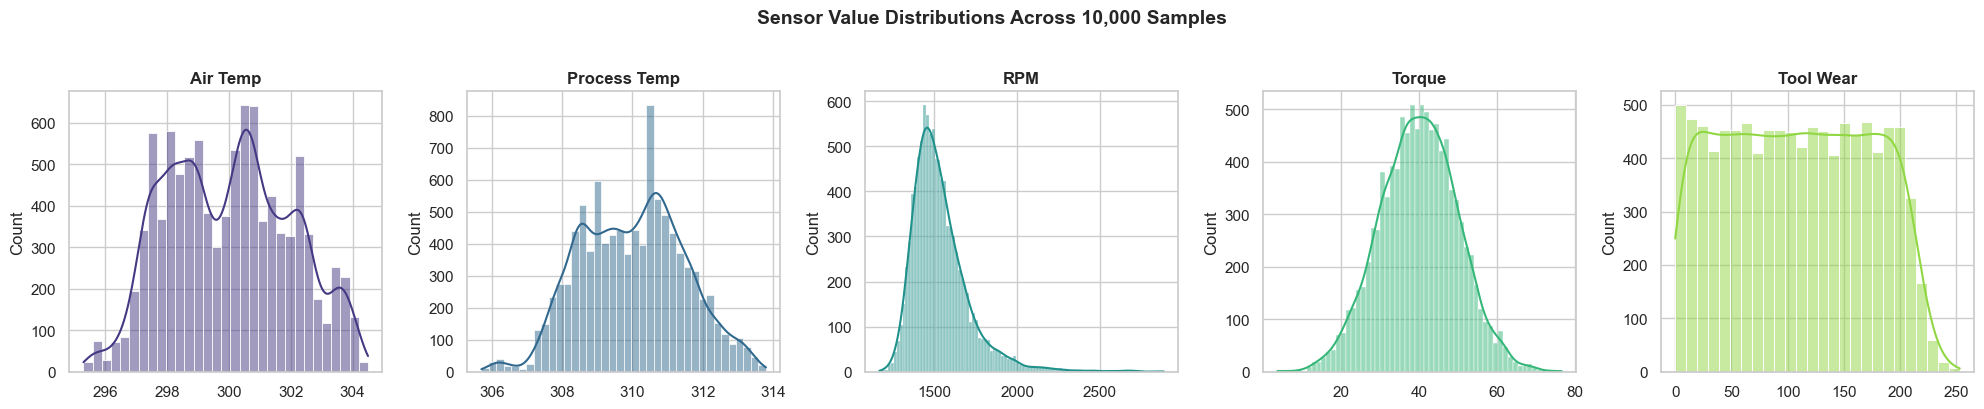

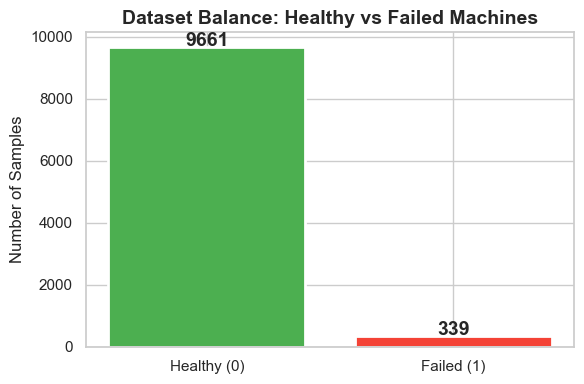

⚠️  Only 3.4% of samples are failures — this is a highly IMBALANCED dataset.
   This is typical in predictive maintenance — most machines operate normally most of the time.


In [4]:
# --- 3.2: Sensor Distributions ---
features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
feature_short = ['Air Temp', 'Process Temp', 'RPM', 'Torque', 'Tool Wear']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (col, name) in enumerate(zip(features, feature_short)):
    sns.histplot(df[col], ax=axes[i], kde=True, color=sns.color_palette('viridis', 5)[i])
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
plt.suptitle('Sensor Value Distributions Across 10,000 Samples', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- 3.3: Failure Balance ---
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Machine failure'].value_counts()
labels = ['Healthy (0)', 'Failed (1)']
colors = ['#4CAF50', '#F44336']
ax.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=2)
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=14)
ax.set_title('Dataset Balance: Healthy vs Failed Machines', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Samples')
plt.tight_layout()
plt.show()

fail_pct = counts[1] / counts.sum() * 100
print(f'⚠️  Only {fail_pct:.1f}% of samples are failures — this is a highly IMBALANCED dataset.')
print('   This is typical in predictive maintenance — most machines operate normally most of the time.')


---
## 🔴 P1 — Binary Failure Prediction (Random Forest)

**Goal:** Given a sensor snapshot, predict whether a failure will occur (binary: Yes / No).

### How it works
- **Algorithm:** Random Forest Classifier (ensemble of many decision trees)
- **Input:** 5 sensor features → **Output:** Probability of failure (0-100%)
- **Threshold:** If probability > 50%, we flag it as ⚠️ DANGER

### Key Visualizations
1. **Feature Importance** — Which sensors drive the prediction the most?
2. **Confusion Matrix** — How accurate is the model on the full dataset?
3. **Failure Probability Distribution** — How confident is the model in its predictions?


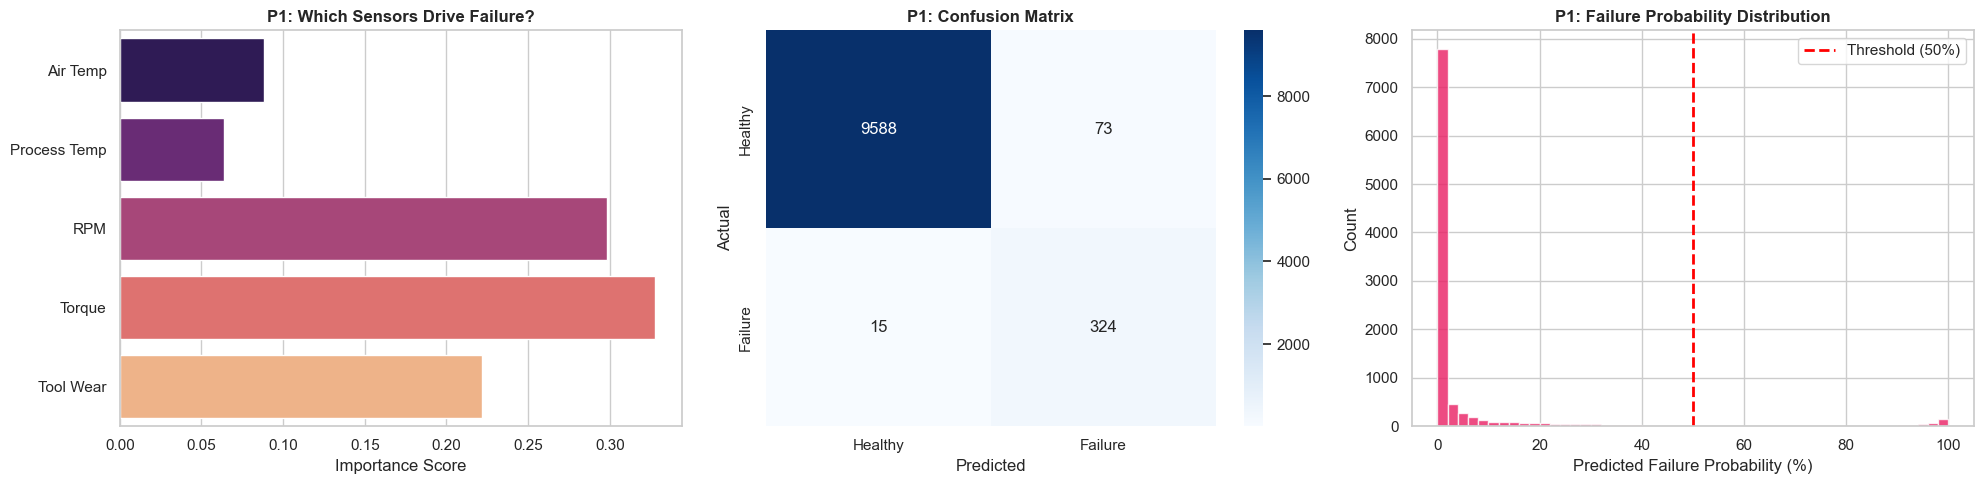

📊 P1 Accuracy on full dataset: 99.1%

📋 Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.99      1.00      9661
     Failure       0.82      0.96      0.88       339

    accuracy                           0.99     10000
   macro avg       0.91      0.97      0.94     10000
weighted avg       0.99      0.99      0.99     10000



In [5]:
# --- P1 Feature Importance ---
importances = model_p1.feature_importances_
feat_names = ['Air Temp', 'Process Temp', 'RPM', 'Torque', 'Tool Wear']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Feature Importance
sns.barplot(x=importances, y=feat_names, hue=feat_names, palette='magma', legend=False, ax=axes[0])
axes[0].set_title('P1: Which Sensors Drive Failure?', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# 2. Confusion Matrix
X = df[features]
y_true = df['Machine failure']
y_pred = model_p1.predict(X)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Healthy', 'Failure'], yticklabels=['Healthy', 'Failure'])
axes[1].set_title('P1: Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# 3. Probability Distribution
y_proba = model_p1.predict_proba(X)[:, 1] * 100
axes[2].hist(y_proba, bins=50, color='#E91E63', edgecolor='white', alpha=0.8)
axes[2].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Threshold (50%)')
axes[2].set_title('P1: Failure Probability Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicted Failure Probability (%)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

# Print classification report
acc = accuracy_score(y_true, y_pred)
print(f'📊 P1 Accuracy on full dataset: {acc*100:.1f}%')
print('\n📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Failure']))


---
## 🟠 P2 — Failure Type Classification (Multi-Output)

**Goal:** When a failure IS predicted, identify the specific **root cause**.

### Failure Types
| Code | Full Name | Description |
|------|-----------|-------------|
| **TWF** | Tool Wear Failure | The cutting tool has worn beyond its useful life |
| **HDF** | Heat Dissipation Failure | Machine overheating due to poor cooling |
| **PWF** | Power Failure | Excessive power draw (RPM × Torque anomaly) |
| **OSF** | Overstrain Failure | Tool is under exceeded strain |
| **RNF** | Random Failure | Unpredictable, stochastic machine failure |

### How it works
- **Algorithm:** Multi-Output Random Forest (one sub-classifier per failure type)
- **Input:** 6 features (5 sensors + temp_delta) → **Output:** Probability for each failure type


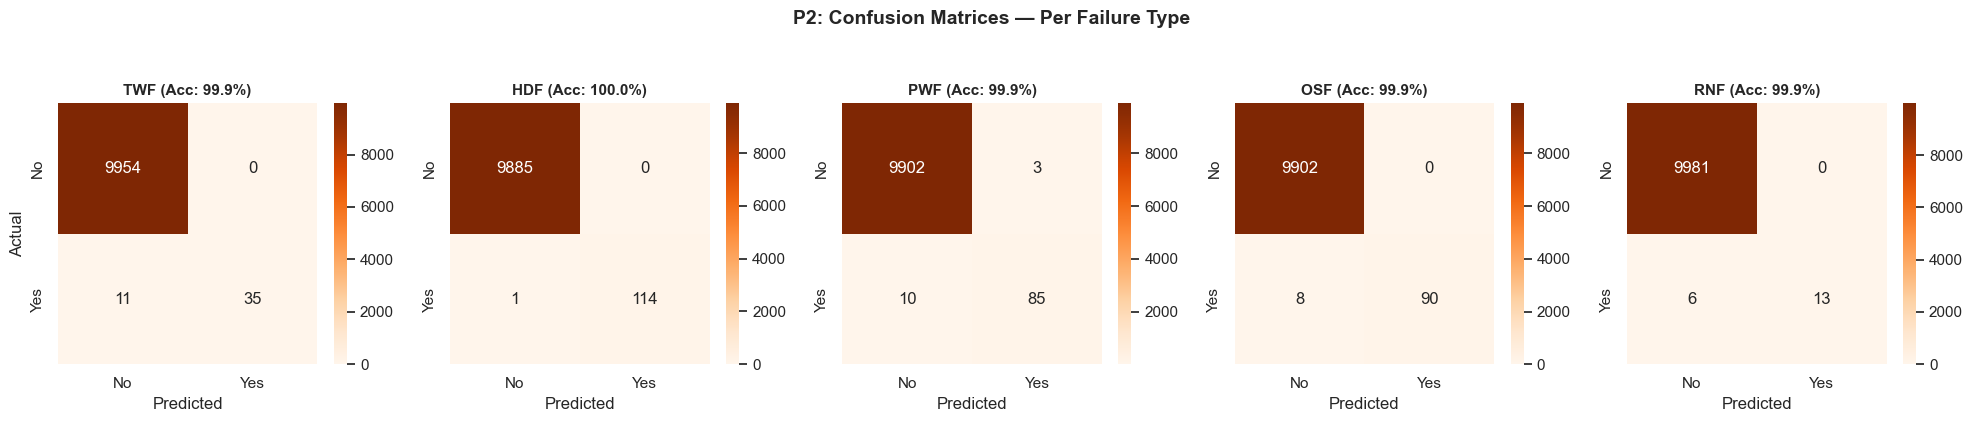

In [6]:
# --- P2 Multi-Output Analysis ---
temp_delta = df['Process temperature [K]'] - df['Air temperature [K]']
X_p2 = df[features].copy()
X_p2['temp_delta'] = temp_delta

fig, axes = plt.subplots(1, len(p2_labels), figsize=(20, 4))

for i, (label, estimator) in enumerate(zip(p2_labels, model_p2.estimators_)):
    y_true_col = df[label]
    y_pred_col = estimator.predict(X_p2)
    
    cm = confusion_matrix(y_true_col, y_pred_col)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[i],
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    acc = accuracy_score(y_true_col, y_pred_col)
    axes[i].set_title(f'{label} (Acc: {acc*100:.1f}%)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    if i == 0:
        axes[i].set_ylabel('Actual')

plt.suptitle('P2: Confusion Matrices — Per Failure Type', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


---
## 🟡 P3 — Remaining Useful Life (RUL) Estimation

**Goal:** Estimate how many cycles the machine can still run before it needs maintenance.

### How it works
- **Algorithm:** Regression Model (trained to predict a continuous RUL value)
- **Input:** 5 sensor features → **Output:** Estimated remaining cycles (positive = healthy, near-zero/negative = critical)

### Key Visualizations
1. **Predicted RUL Distribution** — How are RUL predictions spread across the dataset?
2. **Sensor Correlation Heatmap** — Which sensors are most correlated with failures?


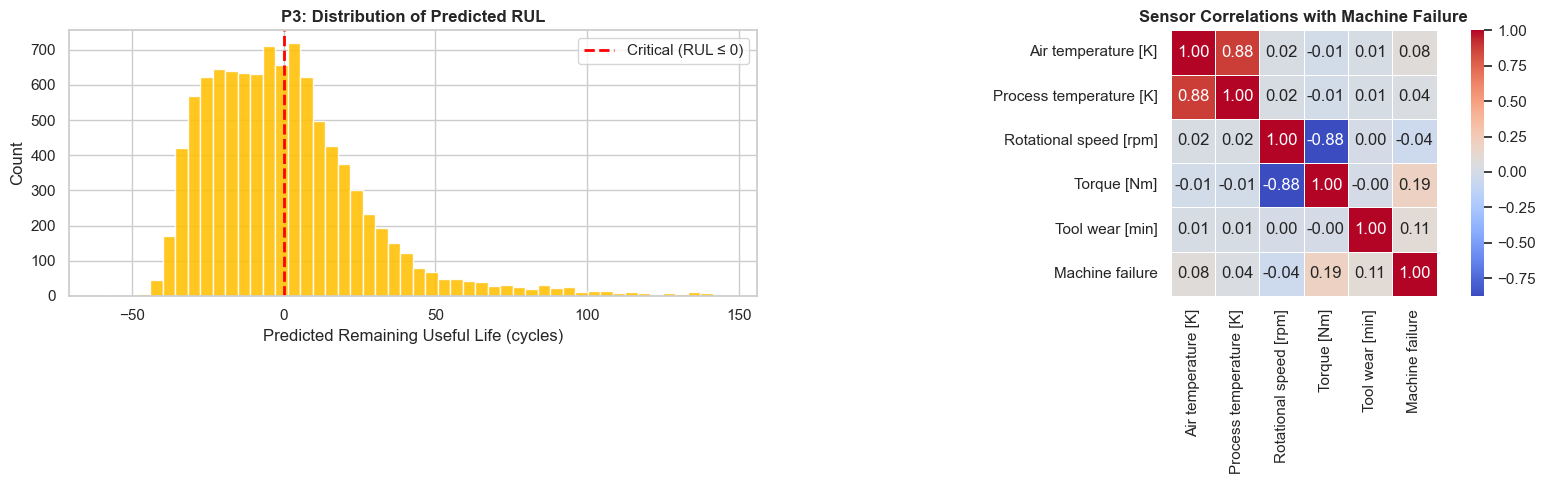

🔴 5525 machines (55.2%) are predicted to have RUL ≤ 0 (critical).


In [7]:
# --- P3 RUL Analysis ---
X_p3 = df[features].rename(columns={
    'Air temperature [K]': 'Air temperature K',
    'Process temperature [K]': 'Process temperature K',
    'Rotational speed [rpm]': 'Rotational speed rpm',
    'Torque [Nm]': 'Torque Nm',
    'Tool wear [min]': 'Tool wear min',
})
predicted_rul = model_p3.predict(X_p3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. RUL Distribution
axes[0].hist(predicted_rul, bins=50, color='#FFC107', edgecolor='white', alpha=0.9)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Critical (RUL ≤ 0)')
axes[0].set_title('P3: Distribution of Predicted RUL', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Remaining Useful Life (cycles)')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. Correlation Heatmap
corr_cols = features + ['Machine failure']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1],
            linewidths=0.5, square=True)
axes[1].set_title('Sensor Correlations with Machine Failure', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

critical_count = (predicted_rul <= 0).sum()
print(f'🔴 {critical_count} machines ({critical_count/len(predicted_rul)*100:.1f}%) are predicted to have RUL ≤ 0 (critical).')


---
## 🟣 P4 — Anomaly Detection (Isolation Forest)

**Goal:** Detect machines that behave **abnormally**, even if they haven't failed yet.

### How it works
- **Algorithm:** Isolation Forest (unsupervised — no labeled data needed)
- **Concept:** Anomalies are data points that are easy to 'isolate' in a random tree
- **Output:** Score value; **negative = anomaly**, **positive = normal**

> 💡 *Unlike P1-P3 which are supervised models, P4 uses unsupervised learning.*  
> This means it can detect **novel failure modes** that the dataset has never seen before.


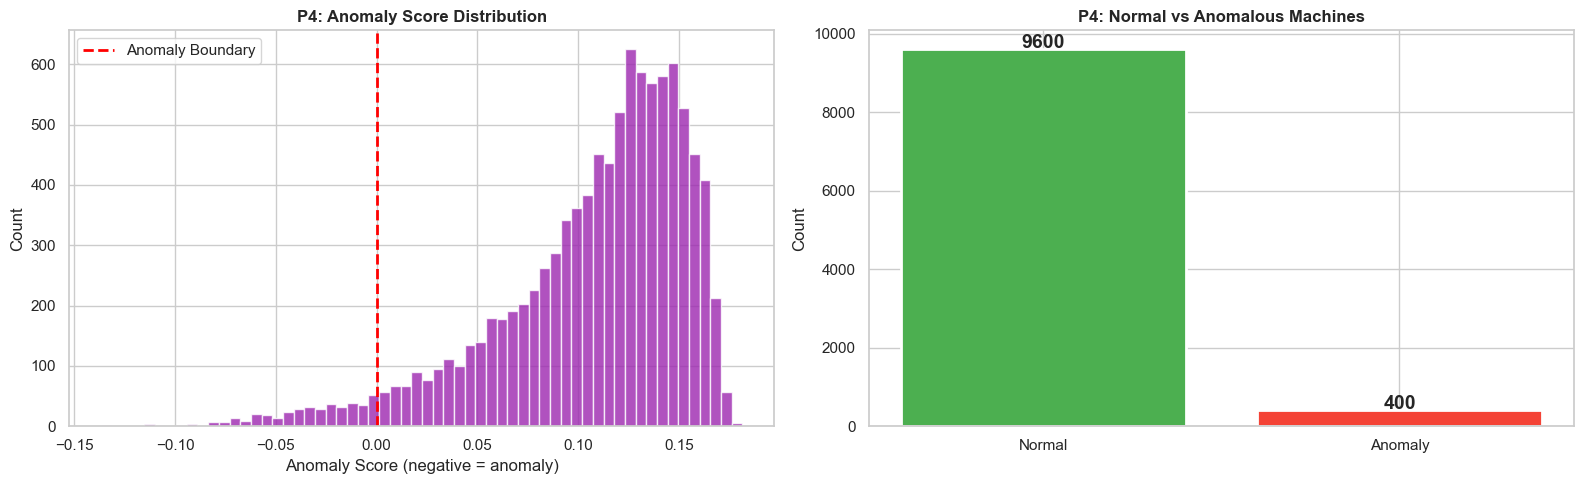

🟣 Anomaly Detection Results:
   ✅ Normal:  9600 (96.0%)
   🚨 Anomaly: 400 (4.0%)


In [8]:
# --- P4 Anomaly Detection Analysis ---
X_p4 = df[features]
anomaly_preds = model_p4.predict(X_p4)  # 1 = normal, -1 = anomaly
anomaly_scores = model_p4.decision_function(X_p4)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Anomaly Score Distribution
axes[0].hist(anomaly_scores, bins=60, color='#9C27B0', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Anomaly Boundary')
axes[0].set_title('P4: Anomaly Score Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Anomaly Score (negative = anomaly)')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. Anomaly vs Normal count
n_anomaly = (anomaly_preds == -1).sum()
n_normal = (anomaly_preds == 1).sum()
bars = axes[1].bar(['Normal', 'Anomaly'], [n_normal, n_anomaly],
                    color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=2)
for bar, val in zip(bars, [n_normal, n_anomaly]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', fontweight='bold', fontsize=14)
axes[1].set_title('P4: Normal vs Anomalous Machines', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'🟣 Anomaly Detection Results:')
print(f'   ✅ Normal:  {n_normal} ({n_normal/len(anomaly_preds)*100:.1f}%)')
print(f'   🚨 Anomaly: {n_anomaly} ({n_anomaly/len(anomaly_preds)*100:.1f}%)')


---
## 🔵 P5 — Work Order Priority Prediction

**Goal:** Once a failure or risk is detected, predict **how urgent** the maintenance action is.

### Priority Levels
- **LOW** — Machine is stable, schedule maintenance at next available window
- **MEDIUM** — Some signs of degradation, plan maintenance soon
- **HIGH** — Significant risk detected, prioritize within the week
- **CRITICAL** — Imminent failure risk, immediate maintenance required

### How it works
- **Algorithm:** Random Forest Classifier
- **Input:** 5 sensor features → **Output:** Priority label (LOW / MEDIUM / HIGH / CRITICAL)


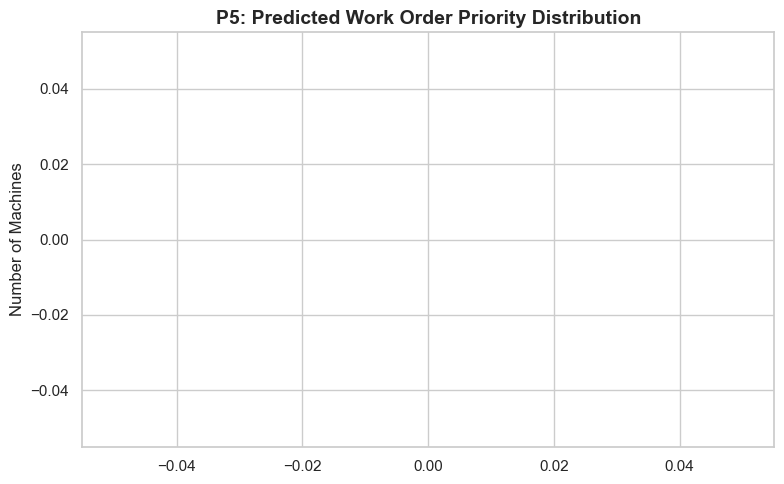

In [9]:
# --- P5 Priority Analysis ---
X_p5 = df[features]
priority_preds = model_p5.predict(X_p5)
priority_labels_pred = [p5_labels[p] for p in priority_preds]

fig, ax = plt.subplots(figsize=(8, 5))
order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
colors = {'LOW': '#4CAF50', 'MEDIUM': '#FF9800', 'HIGH': '#FF5722', 'CRITICAL': '#F44336'}

from collections import Counter
counts = Counter(priority_labels_pred)
labels_ordered = [l for l in order if l in counts]
vals = [counts[l] for l in labels_ordered]
bar_colors = [colors.get(l, '#999') for l in labels_ordered]

bars = ax.bar(labels_ordered, vals, color=bar_colors, edgecolor='white', linewidth=2)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', fontweight='bold', fontsize=13)
ax.set_title('P5: Predicted Work Order Priority Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Machines')
plt.tight_layout()
plt.show()


---
## 🟢 P6 — Maintenance Schedule Optimization

**Goal:** Predict the **optimal number of days** before scheduling maintenance.

### How it works
- **Algorithm:** Random Forest Regressor
- **Input:** 5 sensor features → **Output:** Recommended days until maintenance (0-30 range)
- **Training Logic:** Ground truth derived from distance-to-failure patterns in the dataset:
  - Machine already failing → **0 days** (immediate)
  - Within 5 cycles of failure → **0-1 days**
  - Within 30 cycles → **1-7 days**
  - Within 100 cycles → **7-14 days**
  - Far from failure → **14-30 days**

> 💡 *This model helps operations managers plan maintenance windows optimally —*  
> *not too early (wasting resources) and not too late (risking failure).*


✅ P6 Model Loaded (Maintenance Schedule Optimization)


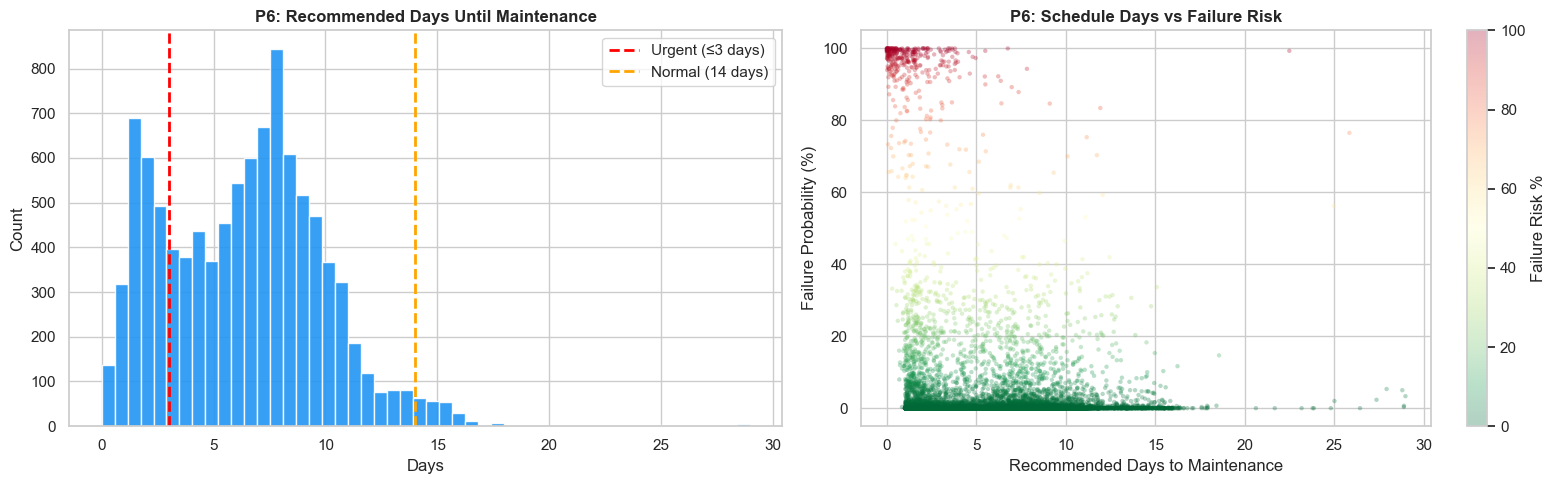

📅 Scheduling Summary:
   🔴 Urgent (0-3 days):  2309 machines (23.1%)
   🟡 Normal (3-14 days): 7458 machines (74.6%)
   🟢 Relaxed (14+ days): 233 machines (2.3%)


In [10]:
# --- P6 Maintenance Schedule Analysis ---
model_p6 = joblib.load(os.path.join(MODELS_DIR, 'ml_model_p6_schedule.pkl'))
print('✅ P6 Model Loaded (Maintenance Schedule Optimization)')

X_p6 = df[features]
schedule_preds = model_p6.predict(X_p6)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Distribution of recommended maintenance days
axes[0].hist(schedule_preds, bins=50, color='#2196F3', edgecolor='white', alpha=0.9)
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=2, label='Urgent (≤3 days)')
axes[0].axvline(x=14, color='orange', linestyle='--', linewidth=2, label='Normal (14 days)')
axes[0].set_title('P6: Recommended Days Until Maintenance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. Schedule vs Failure Risk scatter
y_proba_p6 = model_p1.predict_proba(X_p6)[:, 1] * 100
scatter = axes[1].scatter(schedule_preds, y_proba_p6, c=y_proba_p6, cmap='RdYlGn_r',
                          alpha=0.3, s=10, edgecolors='none')
axes[1].set_title('P6: Schedule Days vs Failure Risk', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recommended Days to Maintenance')
axes[1].set_ylabel('Failure Probability (%)')
plt.colorbar(scatter, ax=axes[1], label='Failure Risk %')

plt.tight_layout()
plt.show()

urgent = (schedule_preds <= 3).sum()
normal = ((schedule_preds > 3) & (schedule_preds <= 14)).sum()
relaxed = (schedule_preds > 14).sum()
print(f'📅 Scheduling Summary:')
print(f'   🔴 Urgent (0-3 days):  {urgent} machines ({urgent/len(schedule_preds)*100:.1f}%)')
print(f'   🟡 Normal (3-14 days): {normal} machines ({normal/len(schedule_preds)*100:.1f}%)')
print(f'   🟢 Relaxed (14+ days): {relaxed} machines ({relaxed/len(schedule_preds)*100:.1f}%)')


---
## 🚀 Step 4 — Interactive Diagnostics Dashboard

The function below **runs ALL 5 models at once** on a single machine's sensor snapshot.  
It produces a professional diagnostic report showing:
- **P1:** Overall failure probability
- **P3:** Estimated remaining useful life
- **P4:** Anomaly detection status
- **P5:** Work order priority level
- **P2:** Detailed root cause breakdown

> 💡 **How to use:** Call `run_ml_diagnostics(air_temp, process_temp, rpm, torque, wear)` with any sensor values.


In [11]:
def run_ml_diagnostics(air_temp, process_temp, rpm, torque, wear):
    # 1. Prepare Inputs
    # P1/P3/P4/P5/P6 use: [air, process, rpm, torque, wear]
    # P2 uses: [air, process, rpm, torque, wear, temp_delta]
    temp_delta = process_temp - air_temp
    input_p1 = np.array([[air_temp, process_temp, rpm, torque, wear]])
    input_p2 = np.array([[air_temp, process_temp, rpm, torque, wear, temp_delta]])

    # 2. Run All 6 Predictions
    prob_fail = model_p1.predict_proba(input_p1)[0, 1] * 100
    predicted_rul = model_p3.predict(input_p1)[0]
    p2_preds = model_p2.predict(input_p2)[0]
    p2_probs = [est.predict_proba(input_p2)[0, 1] * 100 for est in model_p2.estimators_]
    is_anomaly_val = model_p4.predict(input_p1)[0]
    anomaly_score = model_p4.decision_function(input_p1)[0]
    priority_idx = model_p5.predict(input_p1)[0]
    priority_label = p5_labels[priority_idx]
    schedule_days = model_p6.predict(input_p1)[0]
    schedule_days = max(0, schedule_days)

    # 3. Print Professional Report
    print('='*50)
    print('🚀 MACHINE HEALTH DIAGNOSTIC REPORT')
    print('='*50)
    print(f'INPUTS: Temp Ratio: {temp_delta:.1f}K | RPM: {rpm} | Torque: {torque}Nm | Wear: {wear}min')
    print('-'*50)
    
    status_p1 = '⚠️  DANGER' if prob_fail > 50 else '✅ HEALTHY'
    print(f'[P1] FAILURE RISK         : {prob_fail:>6.1f}% -> {status_p1}')
    print(f'[P3] EST. REMAINING LIFE  : {predicted_rul:>6.1f} cycles')

    anom_status = '🚨 ANOMALY DETECTED' if is_anomaly_val == -1 else '✅ NORMAL BEHAVIOR'
    print(f'[P4] ANOMALY STATUS       : {anom_status} (Score: {anomaly_score:.4f})')
    print(f'[P5] WO PRIORITY         :    {priority_label.upper()}')
    print(f'[P6] SCHEDULE MAINT. IN  :    {schedule_days:.1f} days')
    
    print('-'*50)
    print('[P2] ROOT CAUSE ANALYSIS:')
    for label, detected, p2_prob in zip(p2_labels, p2_preds, p2_probs):
        mark = '[X]' if detected == 1 else '[ ]'
        print(f'    {mark} {label:3s}: {p2_prob:>5.1f}% confidence')
    print('='*50)

# --- TEST: Stressed Machine ---
print('\n🔧 Test Case 1: Stressed Machine (high temp, high torque, high wear)')
run_ml_diagnostics(air_temp=302.5, process_temp=312.0, rpm=1350, torque=62.0, wear=235)

# --- TEST: Healthy Machine ---
print('\n🔧 Test Case 2: Healthy Machine (normal conditions)')
run_ml_diagnostics(air_temp=298.0, process_temp=308.0, rpm=1550, torque=38.0, wear=15)

# --- TEST: Extreme Conditions ---
print('\n🔧 Test Case 3: Extreme Conditions (high RPM, high torque, max wear)')
run_ml_diagnostics(air_temp=300.0, process_temp=310.0, rpm=3000, torque=80.0, wear=250)



🔧 Test Case 1: Stressed Machine (high temp, high torque, high wear)
🚀 MACHINE HEALTH DIAGNOSTIC REPORT
INPUTS: Temp Ratio: 9.5K | RPM: 1350 | Torque: 62.0Nm | Wear: 235min
--------------------------------------------------
[P1] FAILURE RISK         :   88.7% -> ⚠️  DANGER
[P3] EST. REMAINING LIFE  :  -13.8 cycles
[P4] ANOMALY STATUS       : 🚨 ANOMALY DETECTED (Score: -0.0161)
[P5] WO PRIORITY         :    CRITICAL
[P6] SCHEDULE MAINT. IN  :    6.9 days
--------------------------------------------------
[P2] ROOT CAUSE ANALYSIS:
    [ ] TWF:  10.0% confidence
    [ ] HDF:   0.5% confidence
    [ ] PWF:   9.5% confidence
    [X] OSF:  92.5% confidence
    [ ] RNF:   6.5% confidence

🔧 Test Case 2: Healthy Machine (normal conditions)
🚀 MACHINE HEALTH DIAGNOSTIC REPORT
INPUTS: Temp Ratio: 10.0K | RPM: 1550 | Torque: 38.0Nm | Wear: 15min
--------------------------------------------------
[P1] FAILURE RISK         :    0.0% -> ✅ HEALTHY
[P3] EST. REMAINING LIFE  :   12.5 cycles
[P4] ANOMALY

---
## 🧪 Step 5 — Systematic Edge Case Testing

To **validate robustness**, we test the pipeline under extreme/unusual conditions:

| Scenario | Risk | Key Parameter |
|----------|------|---------------|
| Ultra-Low RPM | Seizing Risk | RPM = 100 (far below normal ~1500) |
| Extreme Speed | Vibration Risk | RPM = 3000 (far above normal) |
| Heatwave | Thermal Stress | Temps elevated by ~10K |
| Worn-Out Tool | Critical Wear | Wear = 240 min (near max) |
| Over-Torque | Shear Risk | Torque = 95 Nm (extreme high) |


In [12]:
# --- SYSTEMATIC EDGE CASE TESTING ---
print('='*60)
print('🔍 RUNNING EDGE CASE ANALYSIS')
print('='*60)

test_cases = [
    {'name': 'Ultra-Low RPM (Seizing Risk)', 'air': 300, 'proc': 310, 'rpm': 100, 'torque': 80, 'wear': 50},
    {'name': 'Extreme Speed (Vibration Risk)', 'air': 300, 'proc': 310, 'rpm': 3000, 'torque': 10, 'wear': 50},
    {'name': 'Heatwave (Thermal Stress)', 'air': 310, 'proc': 320, 'rpm': 1500, 'torque': 40, 'wear': 100},
    {'name': 'Worn-Out Tool (Critical Wear)', 'air': 300, 'proc': 310, 'rpm': 1500, 'torque': 45, 'wear': 240},
    {'name': 'Over-Torque (Shear Risk)', 'air': 300, 'proc': 310, 'rpm': 1400, 'torque': 95, 'wear': 100},
]

for tc in test_cases:
    print(f'\nTEST: {tc["name"]}')
    run_ml_diagnostics(
        air_temp=tc['air'], 
        process_temp=tc['proc'], 
        rpm=tc['rpm'], 
        torque=tc['torque'], 
        wear=tc['wear']
    )


🔍 RUNNING EDGE CASE ANALYSIS

TEST: Ultra-Low RPM (Seizing Risk)
🚀 MACHINE HEALTH DIAGNOSTIC REPORT
INPUTS: Temp Ratio: 10.0K | RPM: 100 | Torque: 80Nm | Wear: 50min
--------------------------------------------------
[P1] FAILURE RISK         :   57.7% -> ⚠️  DANGER
[P3] EST. REMAINING LIFE  :   -9.6 cycles
[P4] ANOMALY STATUS       : ✅ NORMAL BEHAVIOR (Score: 0.0162)
[P5] WO PRIORITY         :    CRITICAL
[P6] SCHEDULE MAINT. IN  :    3.3 days
--------------------------------------------------
[P2] ROOT CAUSE ANALYSIS:
    [ ] TWF:   0.0% confidence
    [ ] HDF:   0.0% confidence
    [ ] PWF:   9.5% confidence
    [ ] OSF:   0.5% confidence
    [ ] RNF:   0.0% confidence

TEST: Extreme Speed (Vibration Risk)
🚀 MACHINE HEALTH DIAGNOSTIC REPORT
INPUTS: Temp Ratio: 10.0K | RPM: 3000 | Torque: 10Nm | Wear: 50min
--------------------------------------------------
[P1] FAILURE RISK         :  100.0% -> ⚠️  DANGER
[P3] EST. REMAINING LIFE  :   -2.2 cycles
[P4] ANOMALY STATUS       : 🚨 ANOMAL

---
## ✅ Summary & Conclusions

### What we demonstrated
1. **P1 (Failure Prediction)** — Our Random Forest detects machine failures with high accuracy using sensor data
2. **P2 (Failure Type)** — The multi-output classifier identifies root causes (TWF/HDF/PWF/OSF/RNF)
3. **P3 (RUL Estimation)** — The regression model estimates remaining machine life in cycles
4. **P4 (Anomaly Detection)** — The Isolation Forest flags unusual machine behaviors unsupervisedly
5. **P5 (Work Order Priority)** — The classifier prioritizes maintenance actions as LOW/MEDIUM/HIGH/CRITICAL
6. **P6 (Maintenance Scheduling)** — The regressor predicts the optimal days to schedule maintenance

### Key Insights from the Dataset
- The dataset is **highly imbalanced** (~3% failures) — typical for real maintenance scenarios
- **Torque** and **RPM** are the most important features for failure prediction
- Sensor correlations reveal that failures are often linked to extreme temperature differentials
- The P6 model shows a strong inverse relationship between failure risk and recommended maintenance window

### Next Steps
- Integrate these models into the **EAM backend** (`MachineLearningService`)
- Connect to **real-time sensor feeds** for live monitoring
- Implement **retraining pipelines** to keep models up-to-date

---
*Complete 6-model ML pipeline built with scikit-learn and Random Forest ❤️*
